# M5 Forecasting Accuracy - Data Understanding

## Objective

The goal of this project is to understand the M5 Forecasting dataset and build a forecasting model capable of predicting the next 28 days of product demand.

This notebook focuses on understanding the datasets before performing any analysis or modeling.

In [121]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [122]:
calendar = pd.read_csv("../data/raw/calendar.csv")
sales = pd.read_csv("../data/raw/sales_train_validation.csv")
prices = pd.read_csv("../data/raw/sell_prices.csv")
submission = pd.read_csv("../data/raw/sample_submission.csv")

In [123]:
datasets = {
    "Calendar": calendar,
    "Sales": sales,
    "Prices": prices,
    "Submission": submission
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Calendar: (1969, 14)
Sales: (30490, 1919)
Prices: (6841121, 4)
Submission: (60980, 29)


In [124]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    print(df.columns.tolist())


Calendar
--------------------------------------------------
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Sales
--------------------------------------------------
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_8

In [125]:
product_sales = sales.iloc[0, 6:]

print("Total Sales :", product_sales.sum())
print("Average Sales :", round(product_sales.mean(), 3))
print("Maximum Sales :", product_sales.max())
print("Zero Sales Days :", (product_sales == 0).sum())

Total Sales : 600
Average Sales : 0.314
Maximum Sales : 5
Zero Sales Days : 1492


In [126]:
# Number of unique products
sales['item_id'].nunique()

3049

In [127]:
# Number of stores
sales['store_id'].nunique()

10

In [128]:
# Number of categories
sales['cat_id'].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

## Business Question

How are Walmart's products distributed across major product categories?

In [129]:
category_counts = sales["cat_id"].value_counts()

category_counts

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

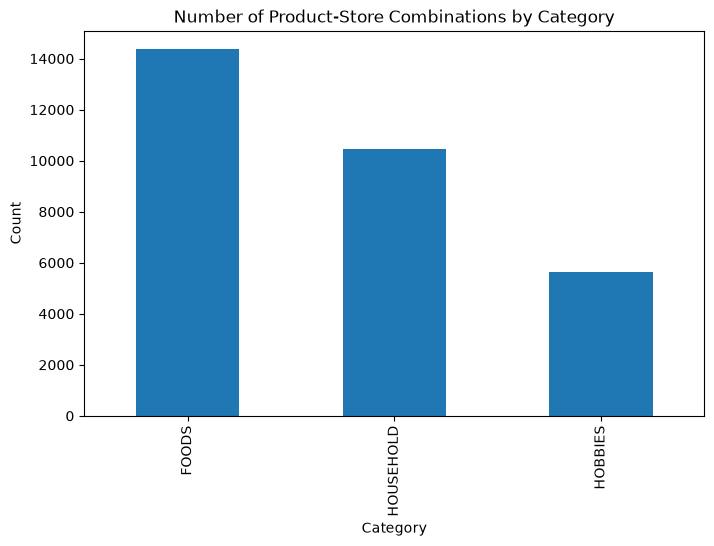

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_counts.plot(kind="bar")

plt.title("Number of Product-Store Combinations by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

### Insights

- Foods account for the largest share of products.
- Household products are the second-largest category.
- Hobbies contains the fewest products.
- The distribution suggests Walmart's inventory is heavily focused on food items.

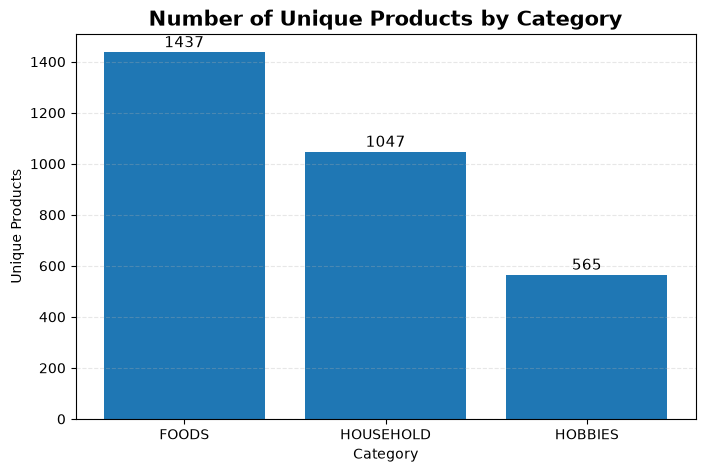

In [131]:
import matplotlib.pyplot as plt

# Count unique products in each category
category_products = (
    sales.groupby("cat_id")["item_id"]
         .nunique()
         .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    category_products.index,
    category_products.values
)

plt.title("Number of Unique Products by Category", fontsize=15, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Unique Products")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

### Insights

- Food products dominate Walmart's product assortment with 1,437 unique items.
- Household products account for 1,047 unique items.
- Hobbies contain only 565 products, making it the smallest category.
- The product portfolio is heavily skewed toward food items, reflecting Walmart's focus on grocery retail.

## Business Question

How have Walmart's total daily sales changed over time?

In [132]:
day_columns = [col for col in sales.columns if col.startswith("d_")]

len(day_columns)

1913

In [133]:
[col for col in sales.columns if col.startswith("d_")]

['d_1',
 'd_2',
 'd_3',
 'd_4',
 'd_5',
 'd_6',
 'd_7',
 'd_8',
 'd_9',
 'd_10',
 'd_11',
 'd_12',
 'd_13',
 'd_14',
 'd_15',
 'd_16',
 'd_17',
 'd_18',
 'd_19',
 'd_20',
 'd_21',
 'd_22',
 'd_23',
 'd_24',
 'd_25',
 'd_26',
 'd_27',
 'd_28',
 'd_29',
 'd_30',
 'd_31',
 'd_32',
 'd_33',
 'd_34',
 'd_35',
 'd_36',
 'd_37',
 'd_38',
 'd_39',
 'd_40',
 'd_41',
 'd_42',
 'd_43',
 'd_44',
 'd_45',
 'd_46',
 'd_47',
 'd_48',
 'd_49',
 'd_50',
 'd_51',
 'd_52',
 'd_53',
 'd_54',
 'd_55',
 'd_56',
 'd_57',
 'd_58',
 'd_59',
 'd_60',
 'd_61',
 'd_62',
 'd_63',
 'd_64',
 'd_65',
 'd_66',
 'd_67',
 'd_68',
 'd_69',
 'd_70',
 'd_71',
 'd_72',
 'd_73',
 'd_74',
 'd_75',
 'd_76',
 'd_77',
 'd_78',
 'd_79',
 'd_80',
 'd_81',
 'd_82',
 'd_83',
 'd_84',
 'd_85',
 'd_86',
 'd_87',
 'd_88',
 'd_89',
 'd_90',
 'd_91',
 'd_92',
 'd_93',
 'd_94',
 'd_95',
 'd_96',
 'd_97',
 'd_98',
 'd_99',
 'd_100',
 'd_101',
 'd_102',
 'd_103',
 'd_104',
 'd_105',
 'd_106',
 'd_107',
 'd_108',
 'd_109',
 'd_110',
 'd_111'

In [134]:
daily_sales = sales[day_columns].sum()

In [120]:
daily_sales.head()

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64

In [135]:
daily_sales.describe()

count     1913.000000
mean     34341.562467
std       7345.905196
min         11.000000
25%      29654.000000
50%      33732.000000
75%      38689.000000
max      57218.000000
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

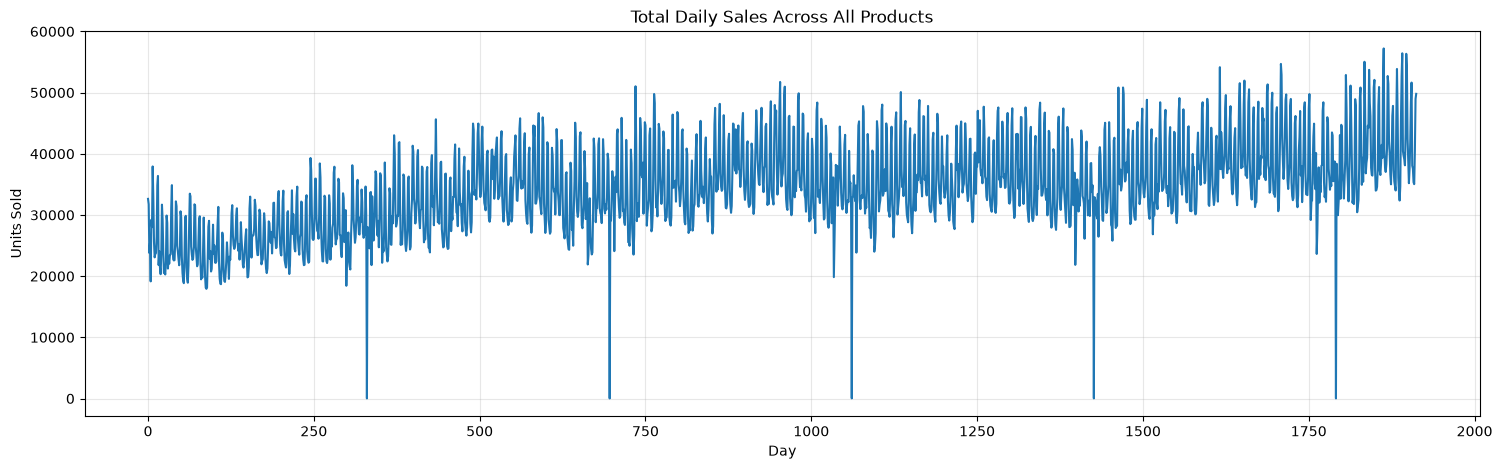

In [136]:
daily_sales = sales.iloc[:, 6:].sum(axis=0)

plt.figure(figsize=(18,5))
plt.plot(daily_sales.values)
plt.title("Total Daily Sales Across All Products")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.grid(alpha=0.3)
plt.show

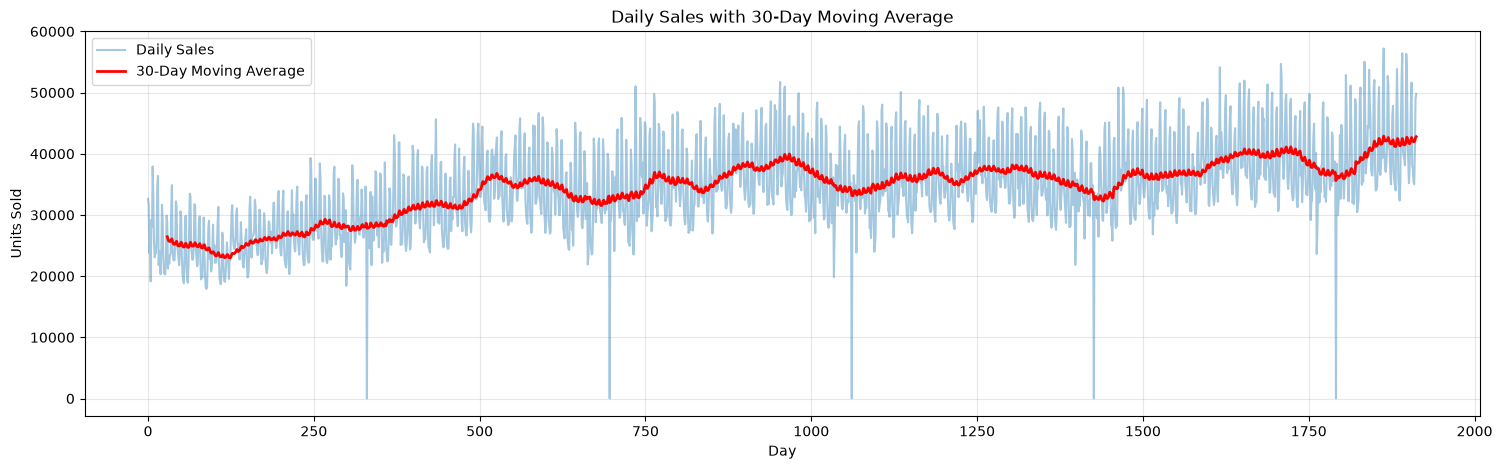

In [138]:
rolling_30 = daily_sales.rolling(window=30).mean()

plt.figure(figsize=(18,5))
plt.plot(daily_sales.values, alpha=0.4, label="Daily Sales")
plt.plot(rolling_30.values, color="red", linewidth=2,
         label="30-Day Moving Average")

plt.title("Daily Sales with 30-Day Moving Average")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [141]:
sales["total_sales"] = sales.iloc[:, 6:].sum(axis=1)

top_products = (
    sales[["id", "cat_id", "dept_id", "total_sales"]]
    .sort_values("total_sales", ascending=False)
)

top_products.head(10)

,id,cat_id,dept_id,total_sales
8412,FOODS_3_090_CA_3_validation,FOODS,FOODS_3,501004
18055,FOODS_3_586_TX_2_validation,FOODS,FOODS_3,385670
21104,FOODS_3_586_TX_3_validation,FOODS,FOODS_3,300244
8908,FOODS_3_586_CA_3_validation,FOODS,FOODS_3,268772
2314,FOODS_3_090_CA_1_validation,FOODS,FOODS_3,254406
29755,FOODS_3_090_WI_3_validation,FOODS,FOODS_3,242868
17559,FOODS_3_090_TX_2_validation,FOODS,FOODS_3,238992
20608,FOODS_3_090_TX_3_validation,FOODS,FOODS_3,229708
17721,FOODS_3_252_TX_2_validation,FOODS,FOODS_3,228306
15006,FOODS_3_586_TX_1_validation,FOODS,FOODS_3,224908


<Figure size 1000x600 with 0 Axes>

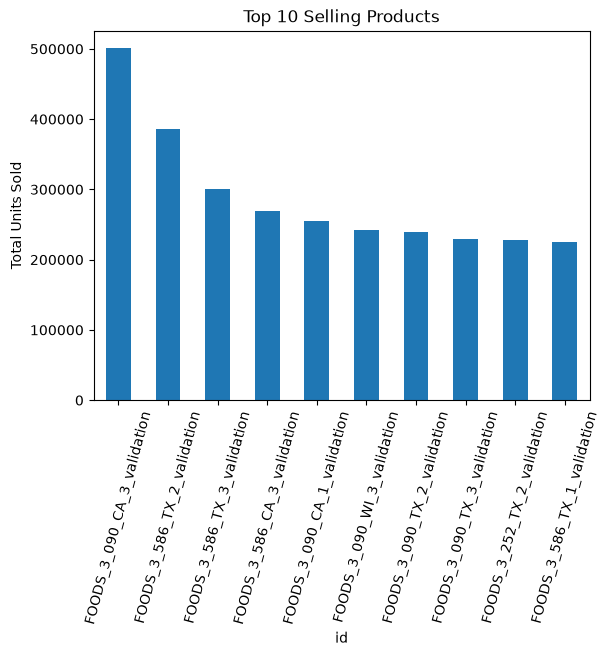

In [143]:
plt.figure(figsize=(10,6))

top_products.head(10).plot(
    x="id",
    y="total_sales",
    kind="bar",
    legend=False
)

plt.title("Top 10 Selling Products")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=75)
plt.show()

In [23]:
%whos

Variable            Type            Data/Info
---------------------------------------------
bar                 Rectangle       Rectangle(xy=(1.6, 0), wi<...>0.8, height=565, angle=0)
bars                BarContainer    <BarContainer object of 3 artists>
calendar            DataFrame       Shape: (1969, 14)
category_counts     Series          Shape: (3,)
category_products   Series          Shape: (3,)
daily_sales         Series          Shape: (1913,)
datasets            dict            n=4
day_columns         list            n=1913
df                  DataFrame       Shape: (60980, 29)
height              int64           565
name                str             Submission
np                  module          <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
pd                  module          <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt                 module          <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
prices              DataFrame       Shape: 

In [144]:
sales["total_sales"] = sales.iloc[:, 6:].sum(axis=1)


In [145]:
sales["total_sales"] = sales.iloc[:, 6:].sum(axis=1)

top_products = (
    sales[["id", "cat_id", "dept_id", "total_sales"]]
    .sort_values("total_sales", ascending=False)
)

top_products.head(10)

,id,cat_id,dept_id,total_sales
8412,FOODS_3_090_CA_3_validation,FOODS,FOODS_3,1002008
18055,FOODS_3_586_TX_2_validation,FOODS,FOODS_3,771340
21104,FOODS_3_586_TX_3_validation,FOODS,FOODS_3,600488
8908,FOODS_3_586_CA_3_validation,FOODS,FOODS_3,537544
2314,FOODS_3_090_CA_1_validation,FOODS,FOODS_3,508812
29755,FOODS_3_090_WI_3_validation,FOODS,FOODS_3,485736
17559,FOODS_3_090_TX_2_validation,FOODS,FOODS_3,477984
20608,FOODS_3_090_TX_3_validation,FOODS,FOODS_3,459416
17721,FOODS_3_252_TX_2_validation,FOODS,FOODS_3,456612
15006,FOODS_3_586_TX_1_validation,FOODS,FOODS_3,449816


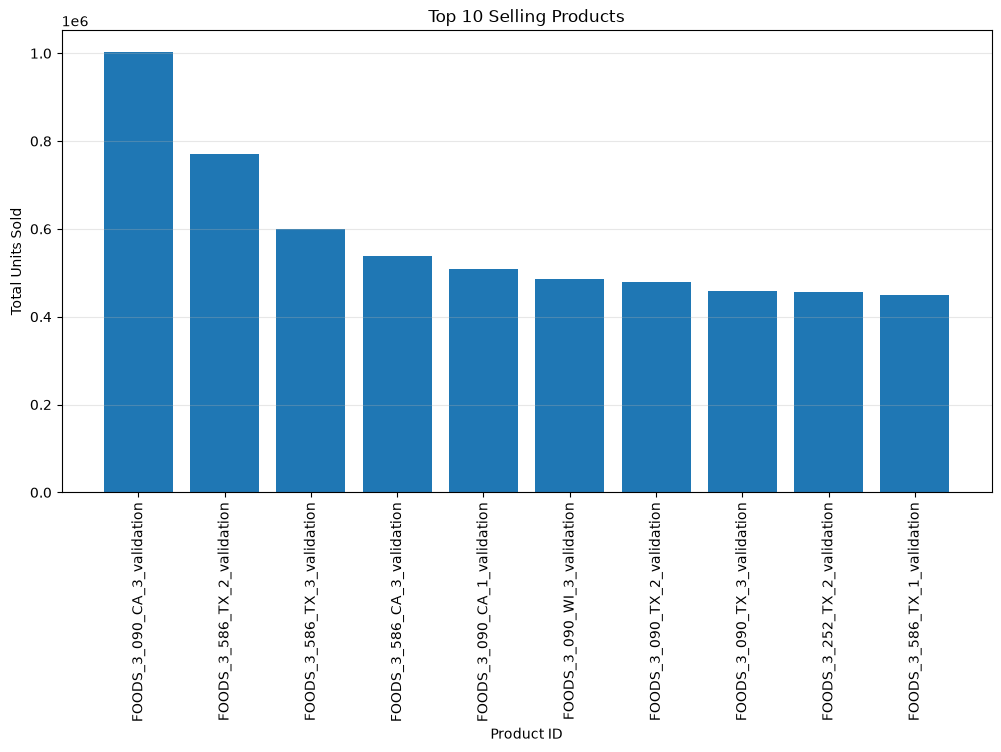

In [146]:
import matplotlib.pyplot as plt

top10 = top_products.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["id"], top10["total_sales"])
plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [147]:
sales["total_sales"] = sales.iloc[:, 6:].sum(axis=1)

In [148]:
top20 = (
    sales[["id","cat_id","dept_id","store_id","total_sales"]]
    .sort_values("total_sales", ascending=False)
)

top20.head(20)

,id,cat_id,dept_id,store_id,total_sales
8412,FOODS_3_090_CA_3_validation,FOODS,FOODS_3,CA_3,1252510
18055,FOODS_3_586_TX_2_validation,FOODS,FOODS_3,TX_2,964175
21104,FOODS_3_586_TX_3_validation,FOODS,FOODS_3,TX_3,750610
8908,FOODS_3_586_CA_3_validation,FOODS,FOODS_3,CA_3,671930
2314,FOODS_3_090_CA_1_validation,FOODS,FOODS_3,CA_1,636015
29755,FOODS_3_090_WI_3_validation,FOODS,FOODS_3,WI_3,607170
17559,FOODS_3_090_TX_2_validation,FOODS,FOODS_3,TX_2,597480
20608,FOODS_3_090_TX_3_validation,FOODS,FOODS_3,TX_3,574270
17721,FOODS_3_252_TX_2_validation,FOODS,FOODS_3,TX_2,570765
15006,FOODS_3_586_TX_1_validation,FOODS,FOODS_3,TX_1,562270


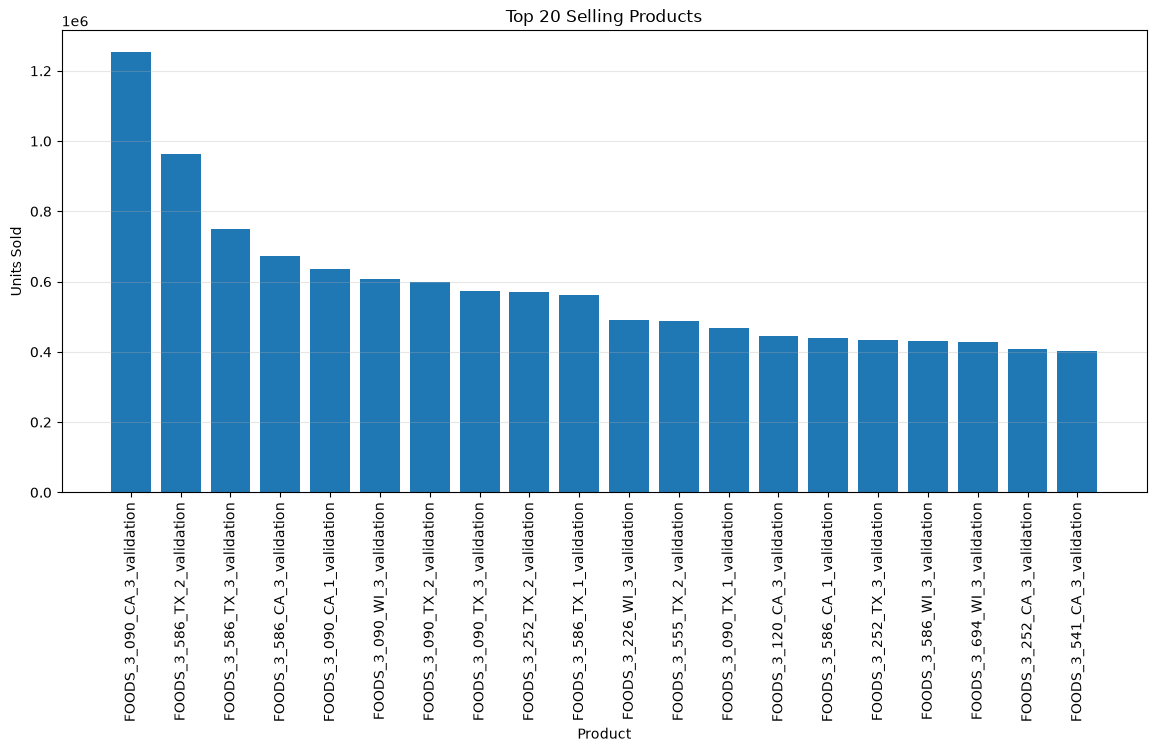

In [149]:
plt.figure(figsize=(14,6))

plt.bar(top20.head(20)["id"],
        top20.head(20)["total_sales"])

plt.xticks(rotation=90)
plt.ylabel("Units Sold")
plt.xlabel("Product")
plt.title("Top 20 Selling Products")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [150]:
bottom20 = (
    sales[["id","cat_id","dept_id","store_id","total_sales"]]
    .sort_values("total_sales")
)

bottom20.head(20)

,id,cat_id,dept_id,store_id,total_sales
6682,HOUSEHOLD_1_020_CA_3_validation,HOUSEHOLD,HOUSEHOLD_1,CA_3,50
6048,FOODS_3_778_CA_2_validation,FOODS,FOODS_3,CA_2,60
27606,HOBBIES_1_170_WI_3_validation,HOBBIES,HOBBIES_1,WI_3,65
20192,FOODS_2_071_TX_3_validation,FOODS,FOODS_2,TX_3,80
26276,FOODS_2_057_WI_2_validation,FOODS,FOODS_2,WI_2,80
6992,HOUSEHOLD_1_336_CA_3_validation,HOUSEHOLD,HOUSEHOLD_1,CA_3,90
6733,HOUSEHOLD_1_073_CA_3_validation,HOUSEHOLD,HOUSEHOLD_1,CA_3,95
10458,HOUSEHOLD_2_216_CA_4_validation,HOUSEHOLD,HOUSEHOLD_2,CA_4,95
10214,HOUSEHOLD_1_512_CA_4_validation,HOUSEHOLD,HOUSEHOLD_1,CA_4,100
10549,HOUSEHOLD_2_307_CA_4_validation,HOUSEHOLD,HOUSEHOLD_2,CA_4,105


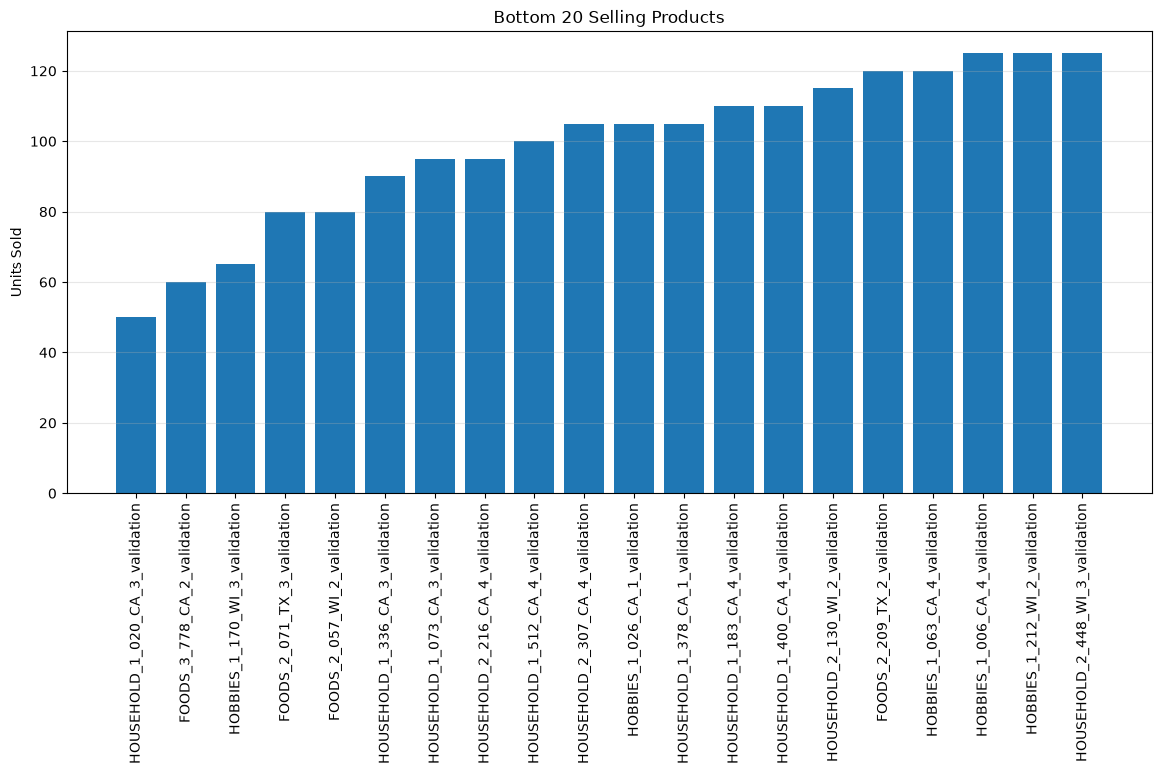

In [151]:
plt.figure(figsize=(14,6))

plt.bar(bottom20.head(20)["id"],
        bottom20.head(20)["total_sales"])

plt.xticks(rotation=90)

plt.title("Bottom 20 Selling Products")
plt.ylabel("Units Sold")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [152]:
category_sales = (
    sales.groupby("cat_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

category_sales

cat_id
FOODS        225449695
HOUSEHOLD     72403350
HOBBIES       30624000
Name: total_sales, dtype: int64

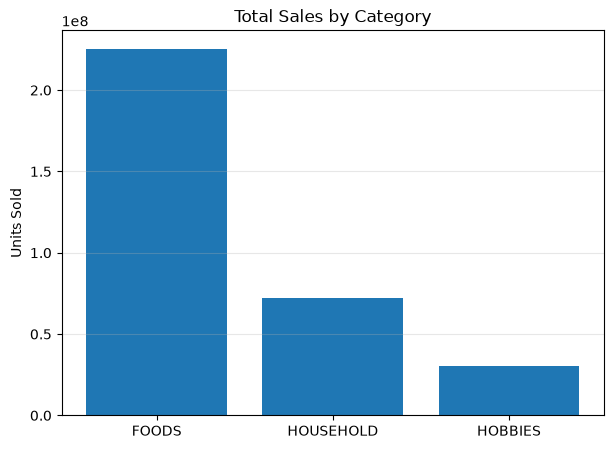

In [153]:
plt.figure(figsize=(7,5))

plt.bar(category_sales.index,
        category_sales.values)

plt.title("Total Sales by Category")
plt.ylabel("Units Sold")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [154]:
dept_sales = (
    sales.groupby("dept_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

dept_sales.head(10)

dept_id
FOODS_3        161860380
HOUSEHOLD_1     57502630
FOODS_2         38149110
HOBBIES_1       27982300
FOODS_1         25440205
HOUSEHOLD_2     14900720
HOBBIES_2        2641700
Name: total_sales, dtype: int64

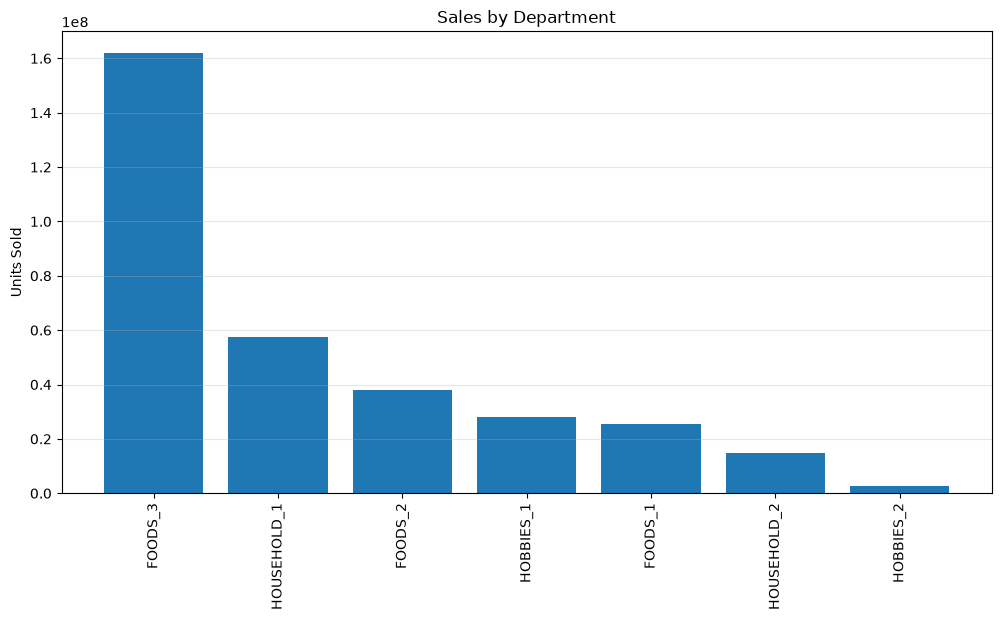

In [155]:
plt.figure(figsize=(12,6))

plt.bar(dept_sales.index,
        dept_sales.values)

plt.xticks(rotation=90)

plt.title("Sales by Department")
plt.ylabel("Units Sold")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [156]:
state_sales = (
    sales.groupby("state_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

state_sales

state_id
CA    143377735
TX     94495030
WI     90604280
Name: total_sales, dtype: int64

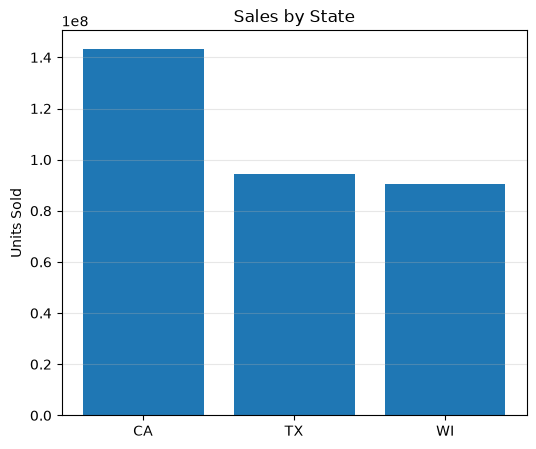

In [158]:
plt.figure(figsize=(6,5))

plt.bar(state_sales.index,
        state_sales.values)

plt.title("Sales by State")
plt.ylabel("Units Sold")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [159]:
store_sales = (
    sales.groupby("store_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

store_sales

store_id
CA_3    55940900
CA_1    38491080
TX_2    36071920
WI_2    32720060
WI_3    32138910
TX_3    30446650
CA_2    28427375
TX_1    27976460
WI_1    25745310
CA_4    20518380
Name: total_sales, dtype: int64

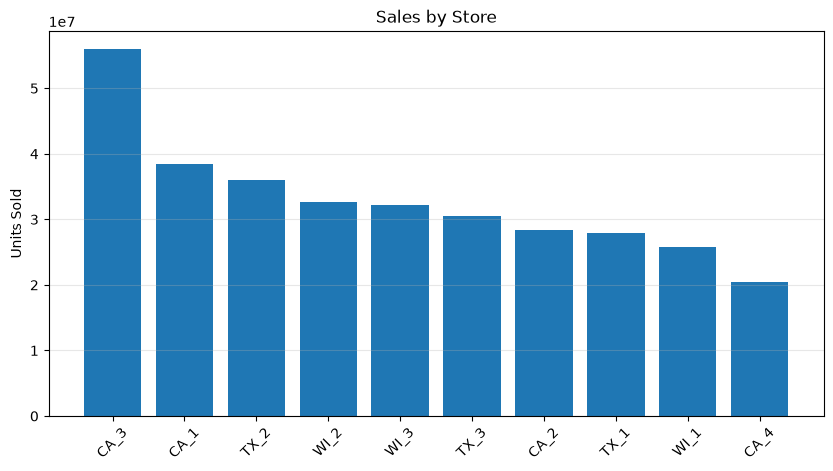

In [160]:
plt.figure(figsize=(10,5))

plt.bar(store_sales.index,
        store_sales.values)

plt.xticks(rotation=45)

plt.title("Sales by Store")
plt.ylabel("Units Sold")

plt.grid(axis='y', alpha=0.3)

plt.show()

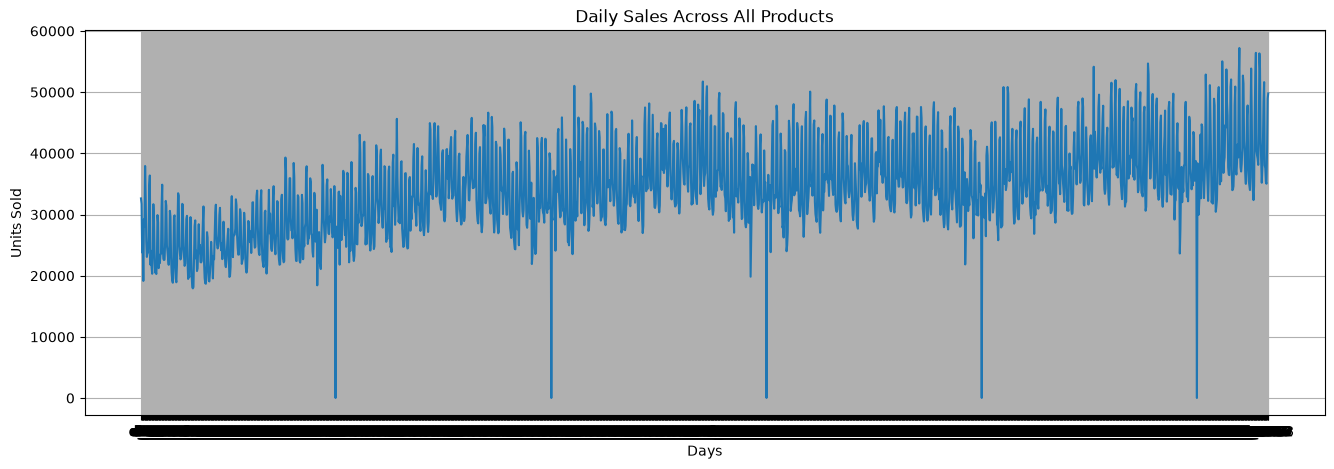

In [161]:
daily_sales = sales[day_columns].sum()

plt.figure(figsize=(16,5))
plt.plot(daily_sales)
plt.title("Daily Sales Across All Products")
plt.xlabel("Days")
plt.ylabel("Units Sold")
plt.grid(True)
plt.show()

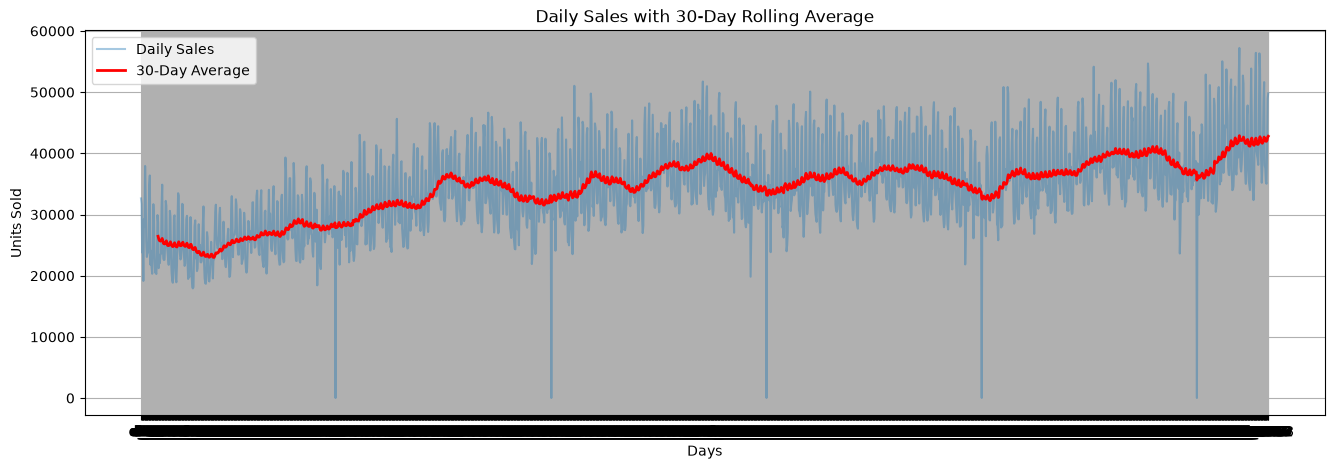

In [162]:
rolling_30 = daily_sales.rolling(30).mean()

plt.figure(figsize=(16,5))
plt.plot(daily_sales, alpha=0.4, label='Daily Sales')
plt.plot(rolling_30, color='red', linewidth=2, label='30-Day Average')

plt.title("Daily Sales with 30-Day Rolling Average")
plt.xlabel("Days")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.show()

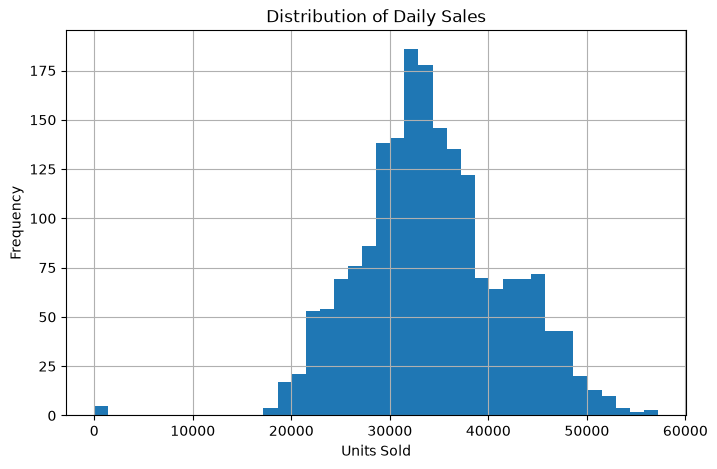

In [165]:
plt.figure(figsize=(8,5))
plt.hist(daily_sales, bins=40)

plt.title("Distribution of Daily Sales")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

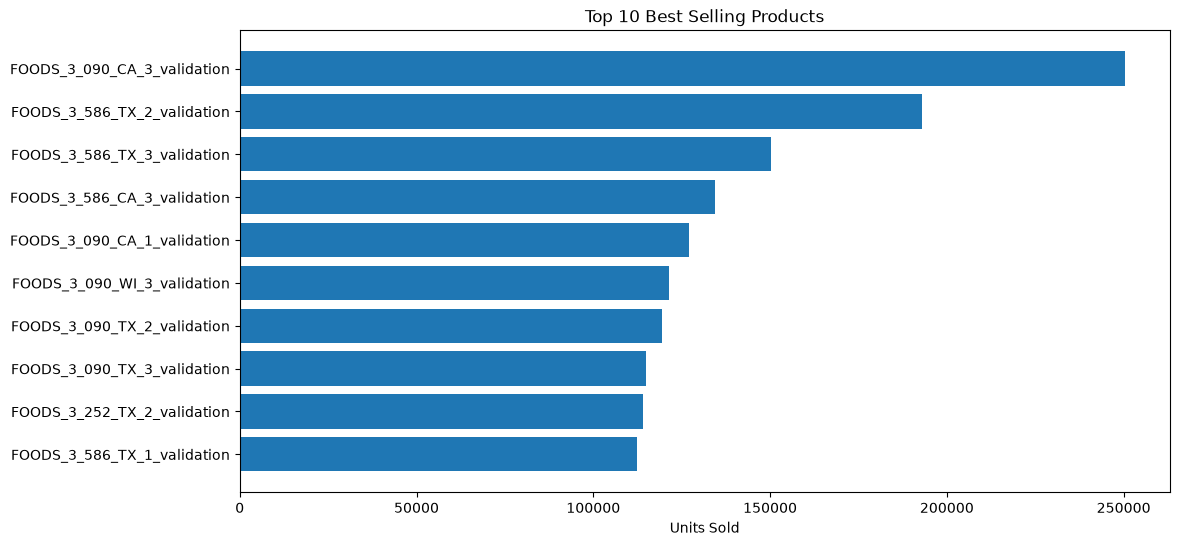

In [166]:
product_sales = sales[day_columns].sum(axis=1)

top10 = sales.loc[
    product_sales.nlargest(10).index,
    ['id']
].copy()

top10['Total Sales'] = product_sales.nlargest(10).values

plt.figure(figsize=(12,6))
plt.barh(top10['id'], top10['Total Sales'])

plt.title("Top 10 Best Selling Products")
plt.xlabel("Units Sold")
plt.gca().invert_yaxis()

plt.show()

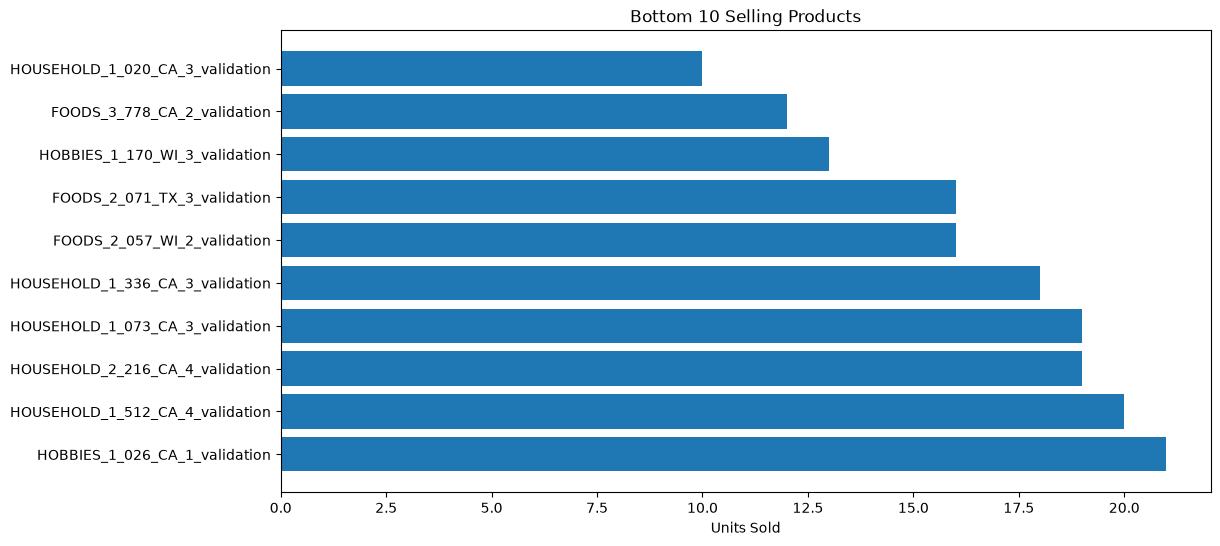

In [167]:
bottom10 = sales.loc[
    product_sales.nsmallest(10).index,
    ['id']
].copy()

bottom10['Total Sales'] = product_sales.nsmallest(10).values

plt.figure(figsize=(12,6))
plt.barh(bottom10['id'], bottom10['Total Sales'])

plt.title("Bottom 10 Selling Products")
plt.xlabel("Units Sold")
plt.gca().invert_yaxis()

plt.show()

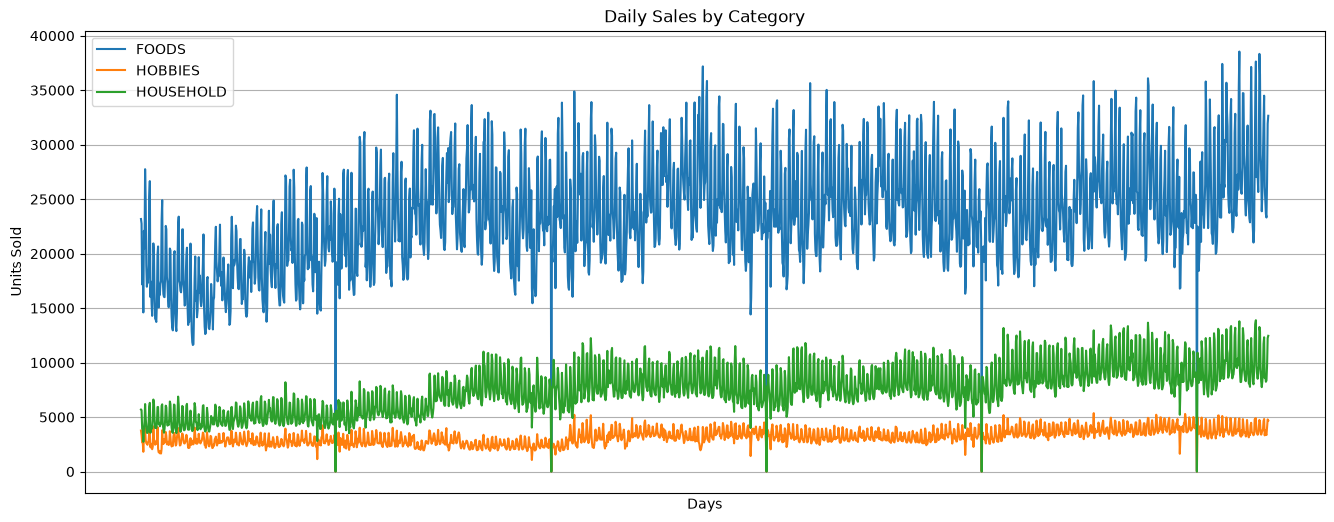

In [168]:
category_daily = sales.groupby('cat_id')[day_columns].sum().T

plt.figure(figsize=(16,6))

for category in category_daily.columns:
    plt.plot(category_daily.index,
             category_daily[category],
             label=category)

plt.title("Daily Sales by Category")
plt.xlabel("Days")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks([])   # Hide crowded day labels
plt.grid(True)

plt.show()

In [169]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [170]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [171]:
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [172]:
daily_sales = sales[day_columns].sum()

calendar_sales = calendar[['d','weekday']].copy()



In [173]:
daily_sales_df = pd.DataFrame({
    'd': day_columns,
    'Sales': daily_sales.values
})

calendar_sales = calendar.merge(daily_sales_df, on='d')

In [174]:
daily_sales = sales[day_columns].sum()

calendar_sales = calendar[['d','weekday']].copy()



In [175]:
calendar_sales = calendar[calendar['d'].isin(day_columns)].copy()

calendar_sales['Sales'] = daily_sales.values

In [176]:
print(calendar_sales.shape)
print(len(daily_sales))

(1913, 15)
1913


In [177]:
calendar_sales.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,Sales
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,32631
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,31749
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,23783
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,25412
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,19146


In [178]:
daily_sales_df = pd.DataFrame({
    'd': day_columns,
    'Sales': daily_sales.values
})

calendar_sales = calendar.merge(daily_sales_df, on='d')

In [185]:
calendar_sales.head()

,d,weekday
0,d_1,Saturday
1,d_2,Sunday
2,d_3,Monday
3,d_4,Tuesday
4,d_5,Wednesday


In [216]:
# Total sales for each day
daily_sales = sales[day_columns].sum()

# Create a copy of calendar
calendar_sales = calendar.copy()

# Keep only the first 1913 days
calendar_sales = calendar_sales.iloc[:len(daily_sales)].copy()

# Add total sales
calendar_sales["Sales"] = daily_sales.values

# Check
print(calendar_sales.shape)
print(calendar_sales.columns)
calendar_sales.head()

(1913, 15)
Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'Sales'],
      dtype='str')


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,Sales
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,32631
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,31749
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,23783
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,25412
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,19146


In [217]:
print(calendar_sales.shape)
print(calendar_sales[['date', 'd', 'Sales']].head())
print(calendar_sales[['date', 'd', 'Sales']].tail())

(1913, 15)
         date    d  Sales
0  2011-01-29  d_1  32631
1  2011-01-30  d_2  31749
2  2011-01-31  d_3  23783
3  2011-02-01  d_4  25412
4  2011-02-02  d_5  19146
            date       d  Sales
1908  2016-04-20  d_1909  35343
1909  2016-04-21  d_1910  35033
1910  2016-04-22  d_1911  40517
1911  2016-04-23  d_1912  48962
1912  2016-04-24  d_1913  49795


In [218]:
weekday_sales = calendar_sales.groupby("weekday")["Sales"].mean()

weekday_sales = weekday_sales.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

print(weekday_sales)

weekday
Monday       32852.967033
Tuesday      30368.780220
Wednesday    30010.021978
Thursday     30205.007326
Friday       34225.985348
Saturday     41546.894161
Sunday       41130.021898
Name: Sales, dtype: float64


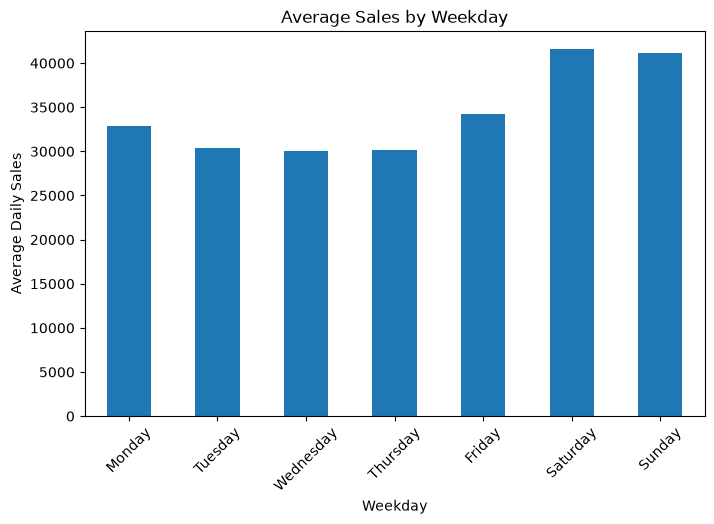

In [219]:
plt.figure(figsize=(8,5))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)

plt.show()

The data shows a clear weekly seasonality. Sales peak on weekends, especially Saturdays, while mid-week sales are comparatively lower. This indicates that customer purchasing behavior is strongly influenced by the day of the week. Therefore, including the weekday as a feature in a forecasting model is likely to improve prediction accuracy.

In [220]:
monthly_sales = calendar_sales.groupby("month")["Sales"].mean()

print(monthly_sales)

month
1     33832.348101
2     34644.641176
3     34339.838710
4     34258.683908
5     32503.851613
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: Sales, dtype: float64


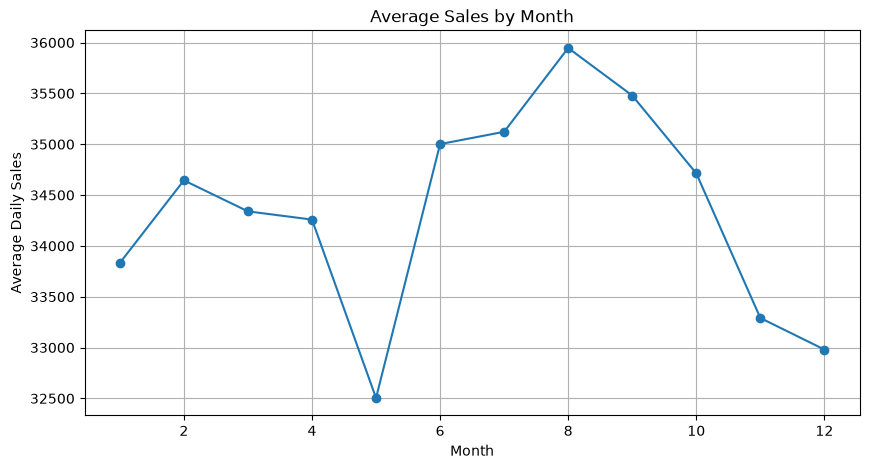

In [221]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.grid(True)

plt.show()

Monthly analysis indicates moderate seasonality. August records the highest average sales, while May shows the lowest. However, the monthly variation is relatively small compared to the strong weekly pattern observed earlier, suggesting that weekday is likely to be a more influential feature than month in the forecasting model.

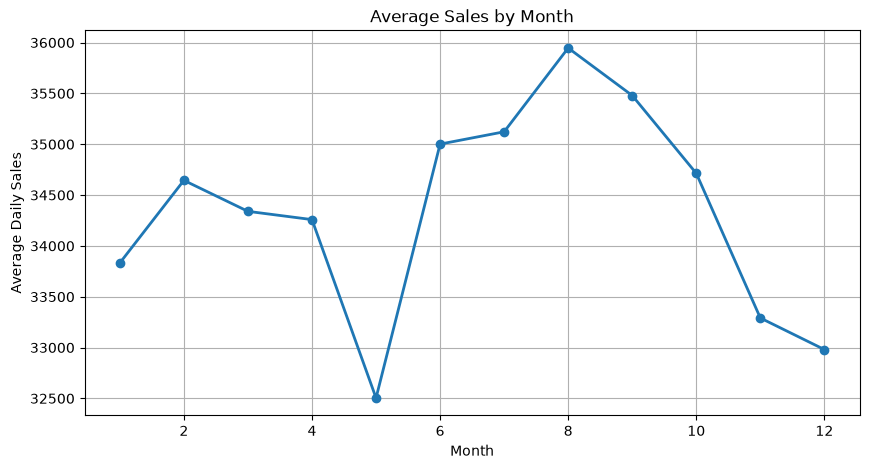

In [222]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o', linewidth=2)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.grid(True)

plt.show()